In [ ]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor

from sklearn.pipeline import Pipeline

from sklearn.compose import ColumnTransformer

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import joblib

### Load Dataset

In [2]:
df = pd.read_csv("/kaggle/input/datasets/vijayaadithyanvg/car-price-predictionused-cars/car data.csv")

## Explore Dataset

In [3]:
print(df.head())

print(df.shape)

print(df.info())

print(df.describe(include='all'))

  Car_Name  Year  Selling_Price  Present_Price  Driven_kms Fuel_Type  \
0     ritz  2014           3.35           5.59       27000    Petrol   
1      sx4  2013           4.75           9.54       43000    Diesel   
2     ciaz  2017           7.25           9.85        6900    Petrol   
3  wagon r  2011           2.85           4.15        5200    Petrol   
4    swift  2014           4.60           6.87       42450    Diesel   

  Selling_type Transmission  Owner  
0       Dealer       Manual      0  
1       Dealer       Manual      0  
2       Dealer       Manual      0  
3       Dealer       Manual      0  
4       Dealer       Manual      0  
(301, 9)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present

## Check Missing Values

In [4]:
df.isnull().sum()

Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Driven_kms       0
Fuel_Type        0
Selling_type     0
Transmission     0
Owner            0
dtype: int64

## Check Duplicate Records

In [5]:
df.duplicated().sum()

np.int64(2)

In [6]:
# Remove duplicates
df.drop_duplicates(inplace=True)

## Understand Features

In [7]:
for col in df.columns:
    print(col)
    print(df[col].unique())
    print("="*50)

Car_Name
['ritz' 'sx4' 'ciaz' 'wagon r' 'swift' 'vitara brezza' 's cross'
 'alto 800' 'ertiga' 'dzire' 'alto k10' 'ignis' '800' 'baleno' 'omni'
 'fortuner' 'innova' 'corolla altis' 'etios cross' 'etios g' 'etios liva'
 'corolla' 'etios gd' 'camry' 'land cruiser' 'Royal Enfield Thunder 500'
 'UM Renegade Mojave' 'KTM RC200' 'Bajaj Dominar 400'
 'Royal Enfield Classic 350' 'KTM RC390' 'Hyosung GT250R'
 'Royal Enfield Thunder 350' 'KTM 390 Duke ' 'Mahindra Mojo XT300'
 'Bajaj Pulsar RS200' 'Royal Enfield Bullet 350'
 'Royal Enfield Classic 500' 'Bajaj Avenger 220' 'Bajaj Avenger 150'
 'Honda CB Hornet 160R' 'Yamaha FZ S V 2.0' 'Yamaha FZ 16'
 'TVS Apache RTR 160' 'Bajaj Pulsar 150' 'Honda CBR 150' 'Hero Extreme'
 'Bajaj Avenger 220 dtsi' 'Bajaj Avenger 150 street' 'Yamaha FZ  v 2.0'
 'Bajaj Pulsar  NS 200' 'Bajaj Pulsar 220 F' 'TVS Apache RTR 180'
 'Hero Passion X pro' 'Bajaj Pulsar NS 200' 'Yamaha Fazer '
 'Honda Activa 4G' 'TVS Sport ' 'Honda Dream Yuga '
 'Bajaj Avenger Street 220' 'He

## Feature Engineering

In [8]:
current_year = 2025

df["Car_Age"] = current_year - df["Year"]

df.drop("Year", axis=1, inplace=True)

In [9]:
# Remove Car Name
df.drop("Car_Name", axis=1, inplace=True)

## Encode Categorical Variables

In [10]:
categorical_columns = [
    "Fuel_Type",
    "Selling_type",
    "Transmission"
]

df = pd.get_dummies(
    df,
    columns=categorical_columns,
    drop_first=True
)

## Correlation Matrix

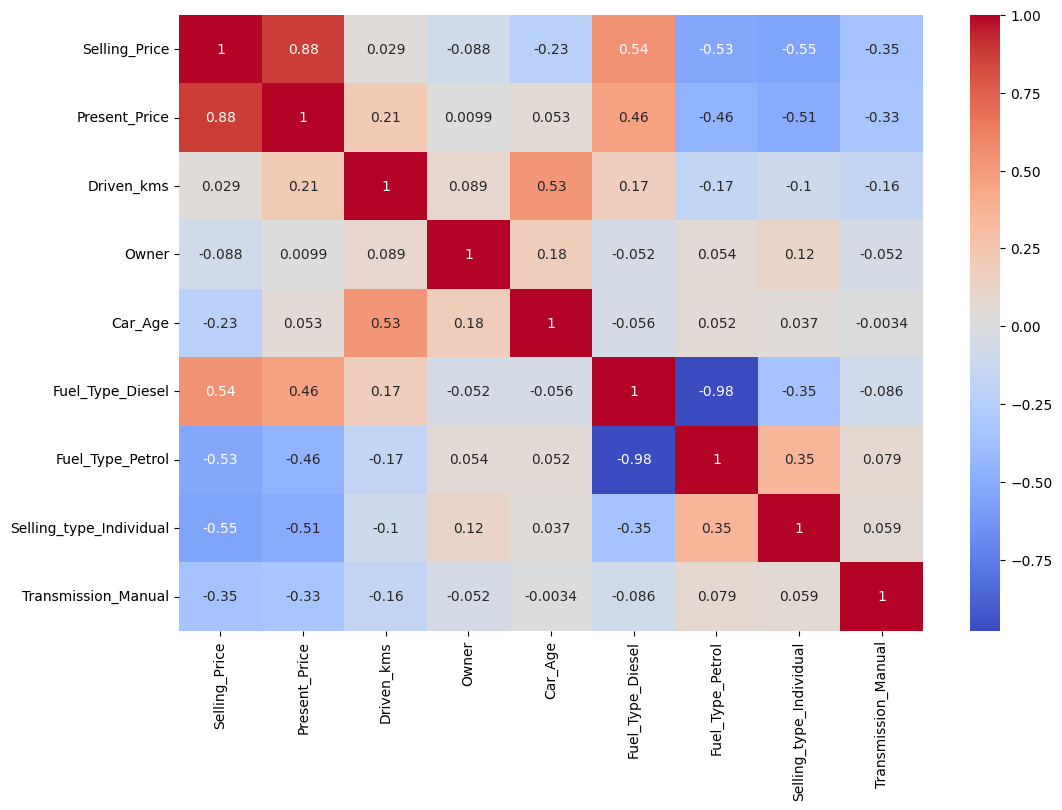

In [11]:
plt.figure(figsize=(12,8))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.show()

## Distribution of Selling Price

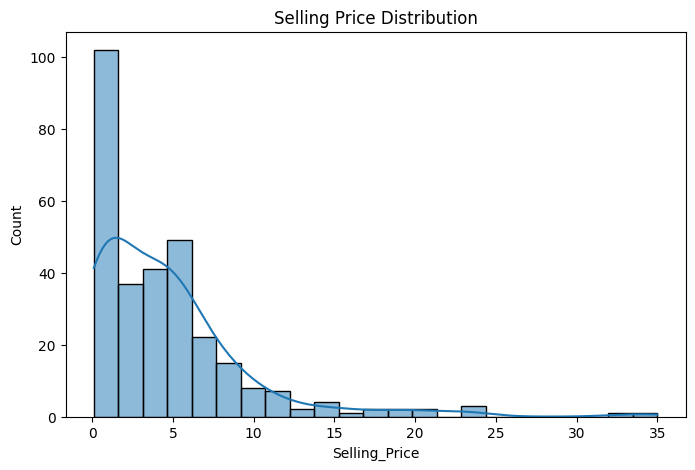

In [12]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["Selling_Price"],
    kde=True
)

plt.title("Selling Price Distribution")

plt.show()

## Boxplot

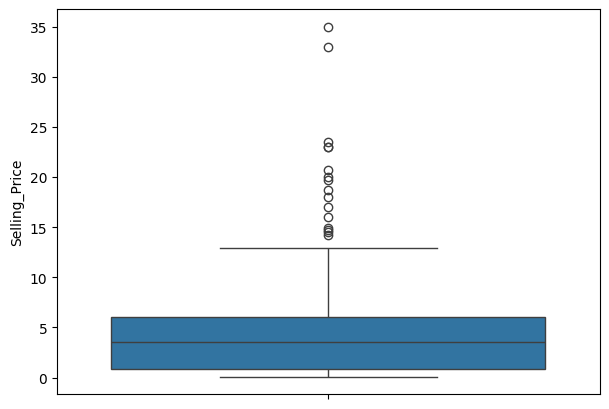

In [13]:
plt.figure(figsize=(7,5))

sns.boxplot(
    y=df["Selling_Price"]
)

plt.show()

## Relationship Between Features

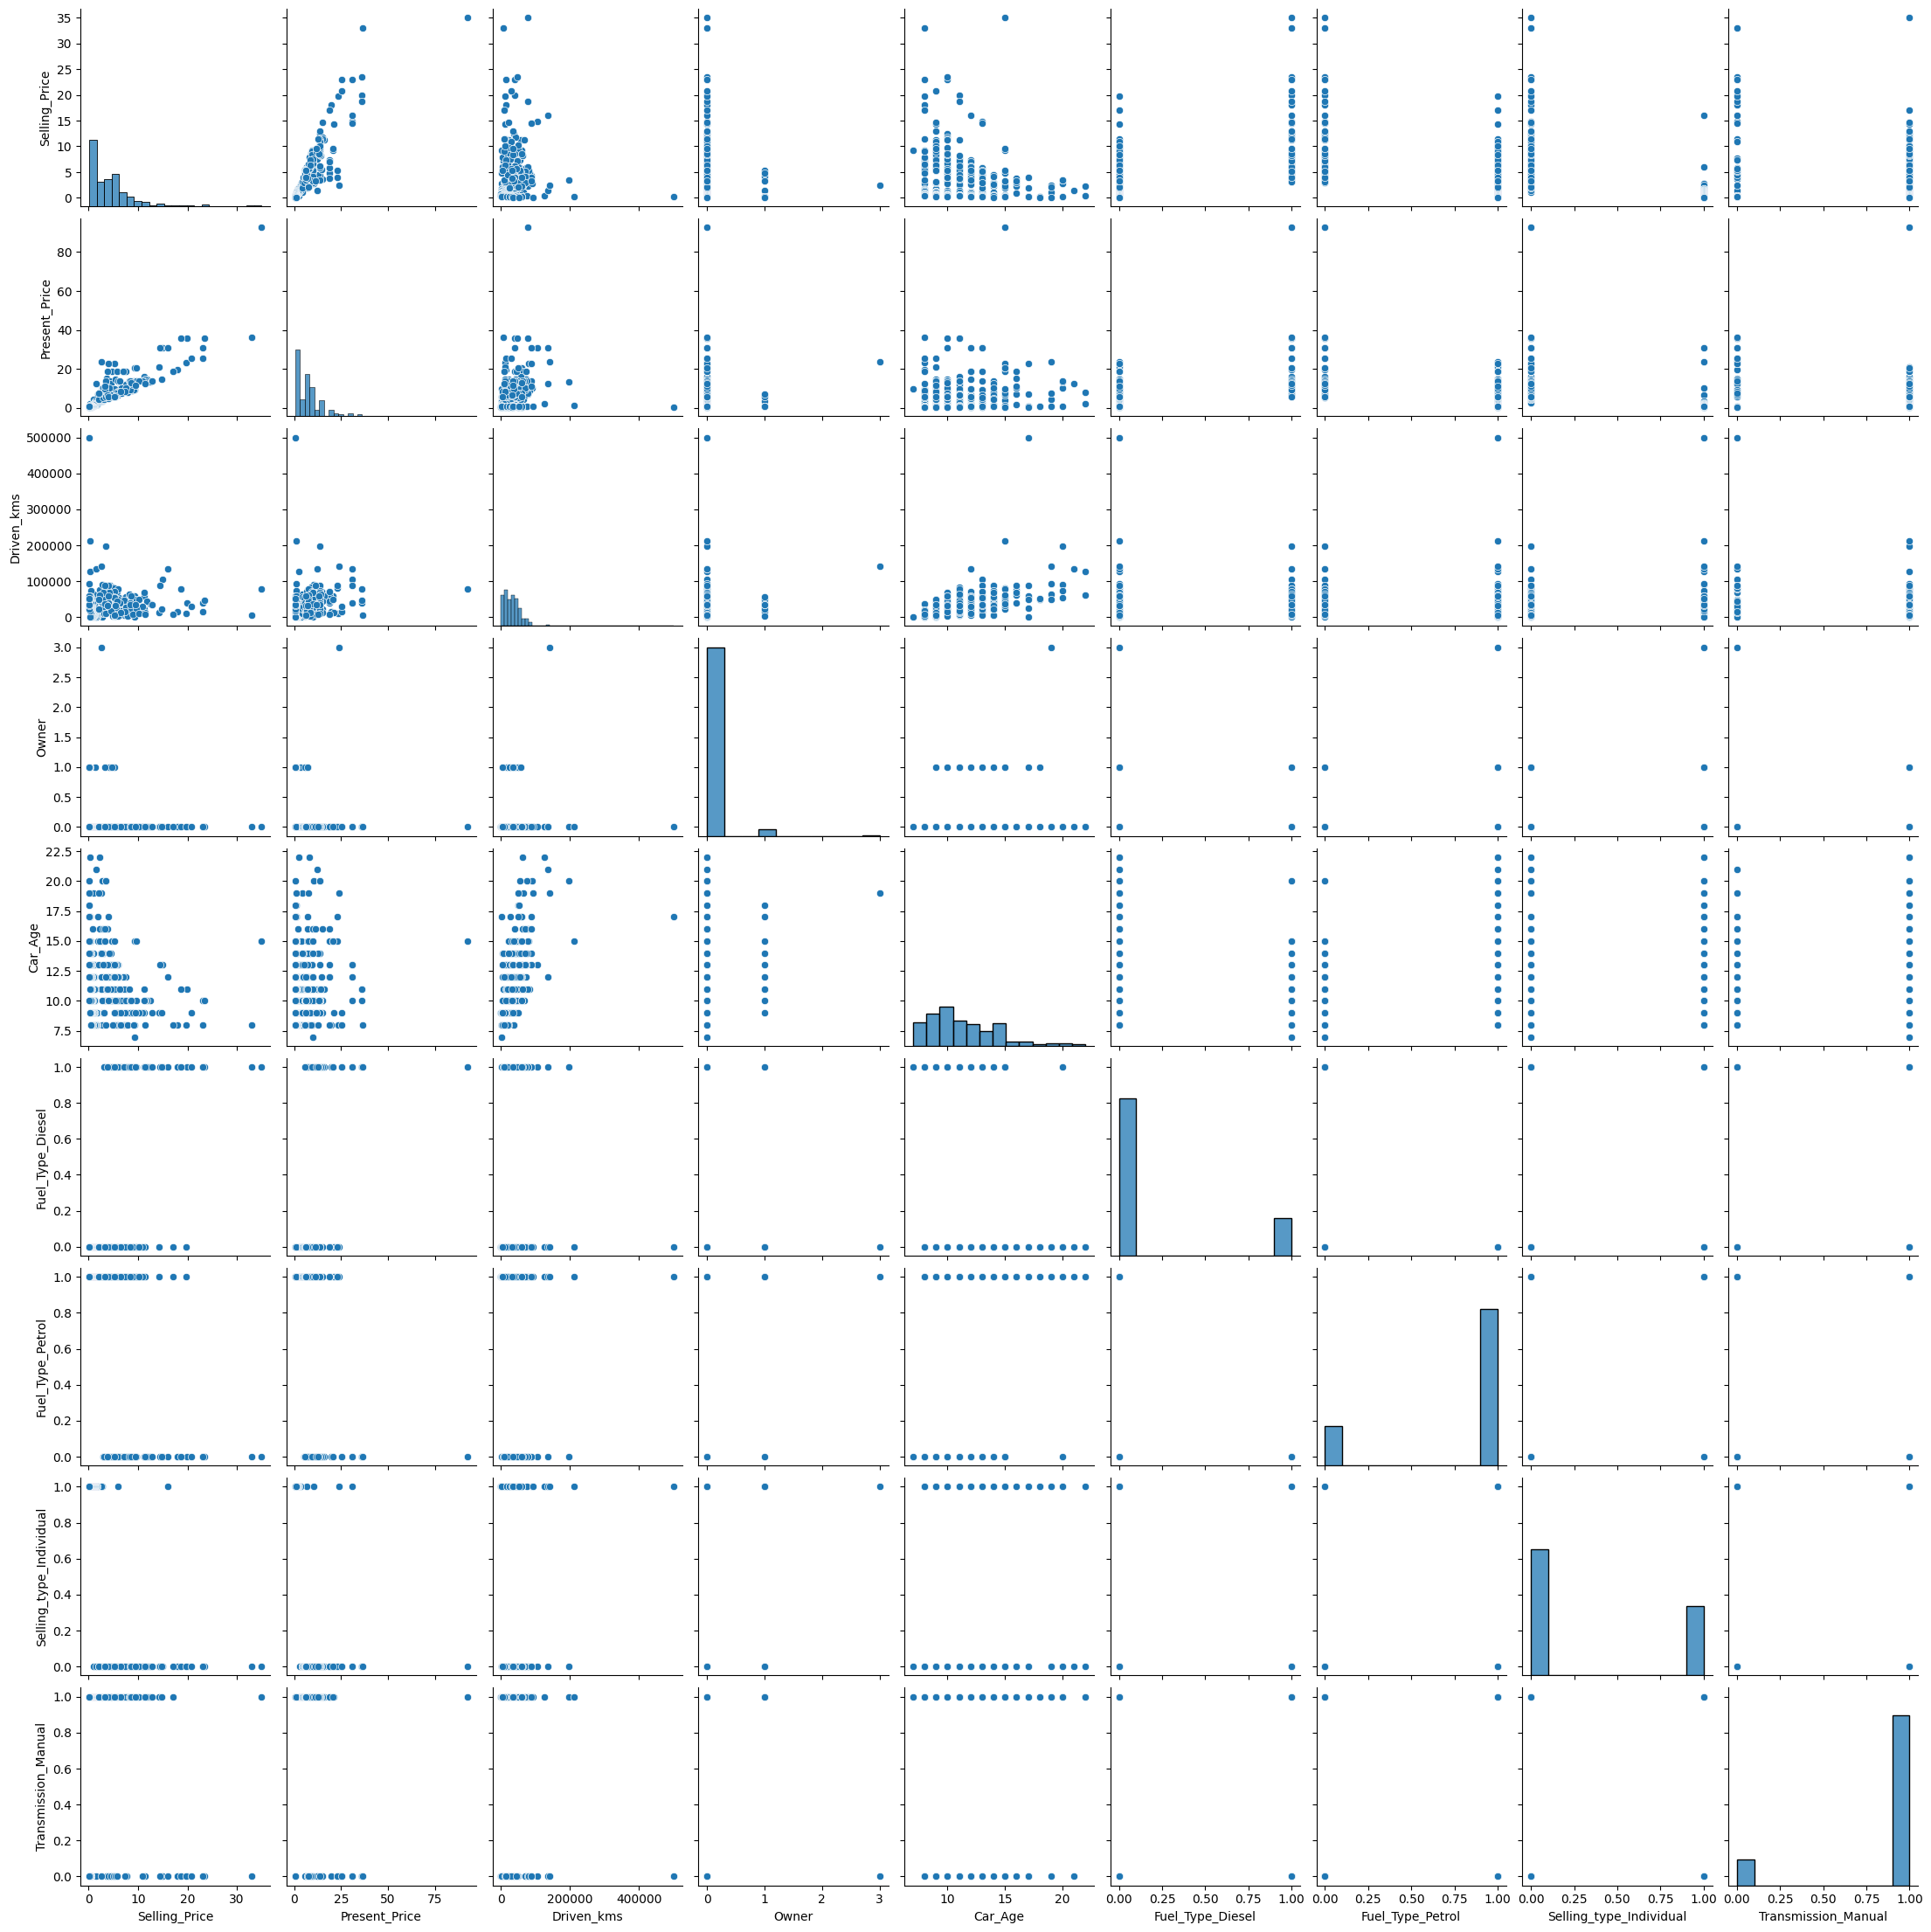

In [14]:
sns.pairplot(df)

plt.show()

## Feature vs Target

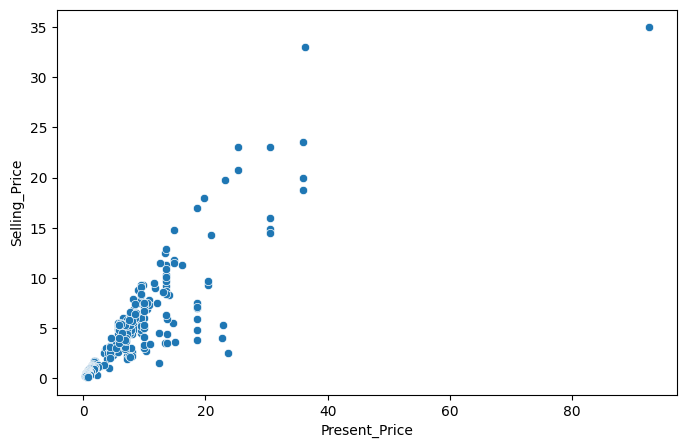

In [15]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x=df["Present_Price"],
    y=df["Selling_Price"]
)

plt.show()

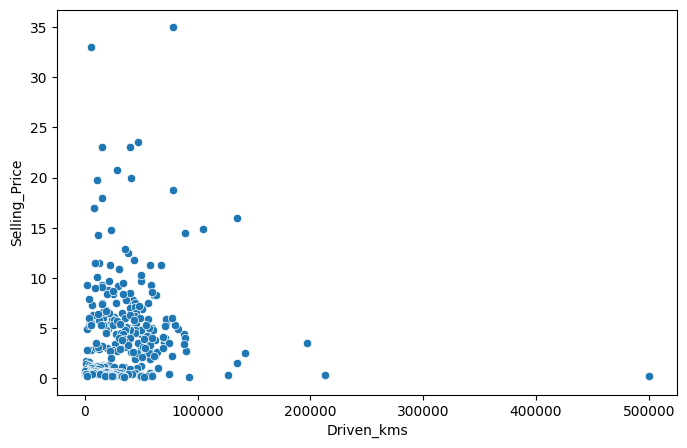

In [16]:
# Mileage
plt.figure(figsize=(8,5))

sns.scatterplot(
    x=df["Driven_kms"],
    y=df["Selling_Price"]
)

plt.show()

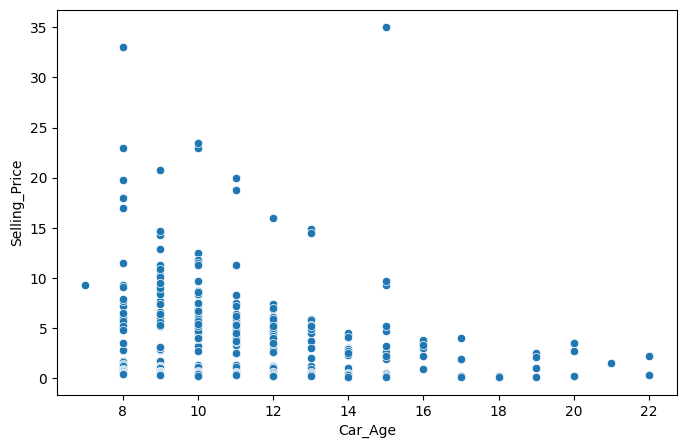

In [17]:
# Car Age
plt.figure(figsize=(8,5))

sns.scatterplot(
    x=df["Car_Age"],
    y=df["Selling_Price"]
)

plt.show()

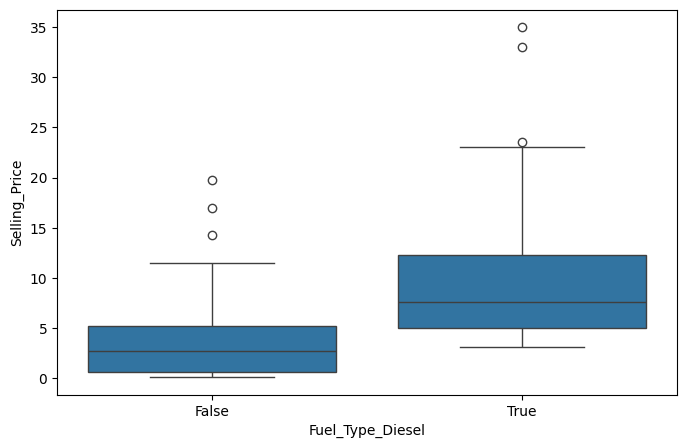

In [18]:
# Fuel Type
plt.figure(figsize=(8,5))

sns.boxplot(
    x="Fuel_Type_Diesel",
    y="Selling_Price",
    data=df
)

plt.show()

## Split Dataset

In [19]:
X = df.drop("Selling_Price", axis=1)

y = df["Selling_Price"]

In [20]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

## Standardization

In [21]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

## Train Multiple Regression Models

In [22]:
models = {

    "Linear Regression": LinearRegression(),

    "Decision Tree": DecisionTreeRegressor(random_state=42),

    "Random Forest": RandomForestRegressor(random_state=42),

    "Gradient Boosting": GradientBoostingRegressor(random_state=42),

    "Extra Trees": ExtraTreesRegressor(random_state=42),

    "Support Vector": SVR(),

    "KNN": KNeighborsRegressor()

}

## Train and Evaluate

In [23]:
results = []

for name, model in models.items():

    model.fit(X_train, y_train)

    pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, pred)

    mse = mean_squared_error(y_test, pred)

    rmse = np.sqrt(mse)

    r2 = r2_score(y_test, pred)

    results.append([name, mae, rmse, r2])

In [24]:
results = pd.DataFrame(
    results,
    columns=["Model","MAE","RMSE","R2 Score"]
)

In [25]:
results.sort_values(
    "R2 Score",
    ascending=False
)

,Model,MAE,RMSE,R2 Score
6,KNN,1.135967,2.052329,0.836573
1,Decision Tree,1.108500,2.105621,0.827975
4,Extra Trees,1.006538,2.128525,0.824213
0,Linear Regression,1.472546,2.524505,0.752723
3,Gradient Boosting,1.184252,2.664503,0.724537
5,Support Vector,1.244431,3.209797,0.600252
2,Random Forest,1.464943,3.509543,0.522106


## Best Model

In [26]:
best_model = RandomForestRegressor(random_state=42)

best_model.fit(X_train,y_train)

prediction = best_model.predict(X_test)

## Actual vs Predicted

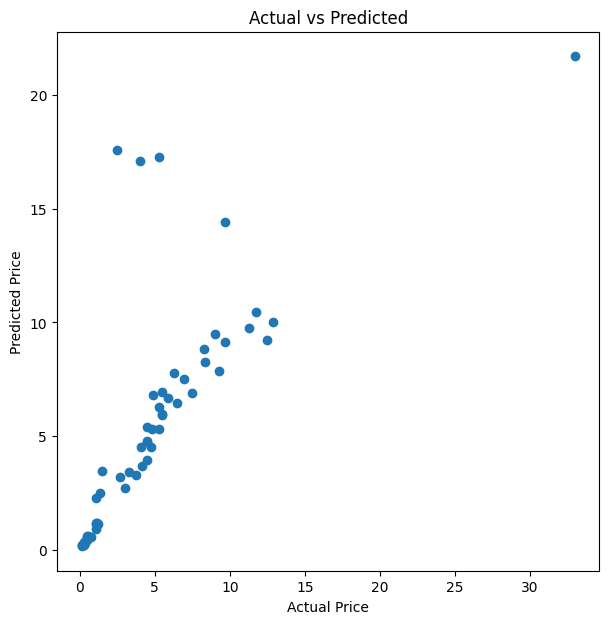

In [27]:
plt.figure(figsize=(7,7))

plt.scatter(y_test,prediction)

plt.xlabel("Actual Price")

plt.ylabel("Predicted Price")

plt.title("Actual vs Predicted")

plt.show()

## Residual Plot

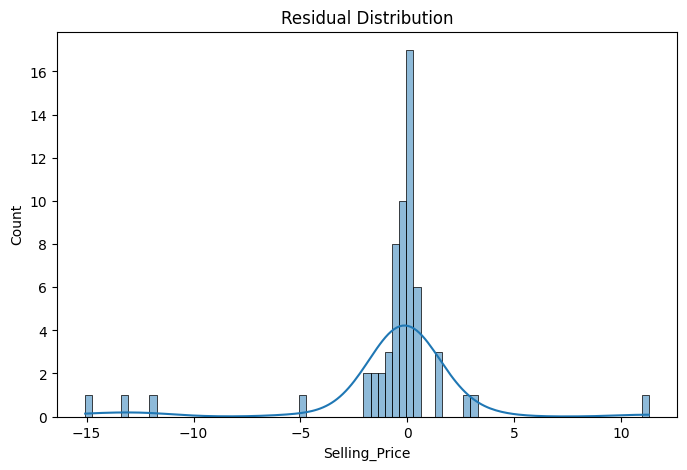

In [28]:
residuals = y_test-prediction

plt.figure(figsize=(8,5))

sns.histplot(residuals,kde=True)

plt.title("Residual Distribution")

plt.show()

## Feature Importance

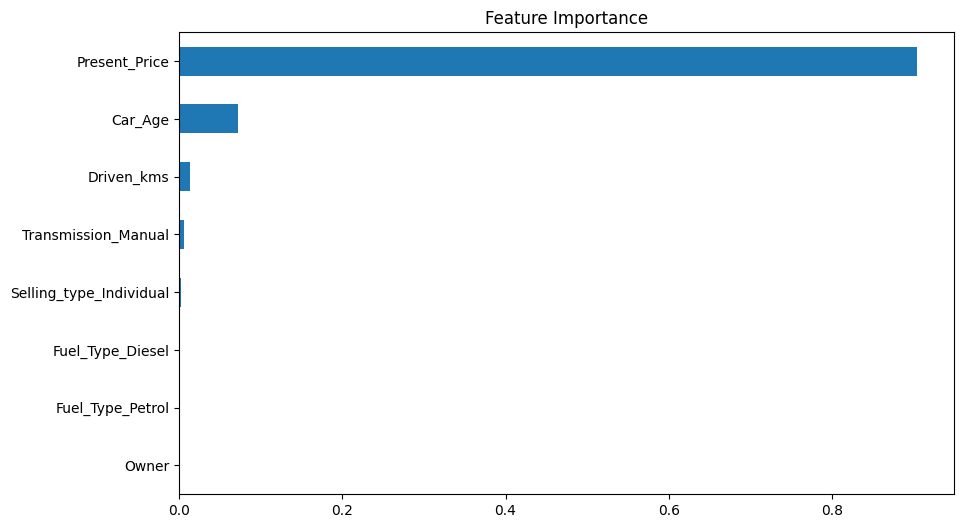

In [29]:
importance = pd.Series(
    best_model.feature_importances_,
    index=X.columns
)

importance.sort_values().plot(
    kind="barh",
    figsize=(10,6)
)

plt.title("Feature Importance")

plt.show()

## Predict New Car Price

In [30]:
sample = X.iloc[[0]]

sample_scaled = scaler.transform(sample)

predicted_price = best_model.predict(sample_scaled)

print(predicted_price)

[3.5815]


## Save Model

In [31]:
joblib.dump(best_model,"car_price_model.pkl")

joblib.dump(scaler,"scaler.pkl")

['scaler.pkl']